In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD, RMSprop, Adam, Nadam
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from scipy.stats import pearsonr
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
data = pd.read_csv('Impute_misvalues_hungyen.csv')
data.head()

,Date,Hour,Waterlevel
0,01/01/2008,0,47.0
1,01/01/2008,1,43.0
2,01/01/2008,2,40.0
3,01/01/2008,3,37.0
4,01/01/2008,4,34.0


In [3]:
data['Hour'] = data['Hour'].replace('#NUM!', 0)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64061 entries, 0 to 64060
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        64061 non-null  object 
 1   Hour        64061 non-null  int64  
 2   Waterlevel  64061 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.5+ MB


In [4]:
data.describe()

,Hour,Waterlevel
count,64061.000000,64061.000000
mean,11.499259,138.135113
std,6.922490,97.020489
min,0.000000,-26.000000
25%,5.000000,75.000000
50%,11.000000,116.000000
75%,17.000000,171.000000
max,23.000000,651.000000


In [5]:
data.isnull().sum()

Date          0
Hour          0
Waterlevel    0
dtype: int64

In [6]:
data['Hour'] = pd.to_datetime(data['Hour'], format='%H', errors='coerce').dt.time
data.head()

,Date,Hour,Waterlevel
0,01/01/2008,00:00:00,47.0
1,01/01/2008,01:00:00,43.0
2,01/01/2008,02:00:00,40.0
3,01/01/2008,03:00:00,37.0
4,01/01/2008,04:00:00,34.0


In [7]:
scaler = StandardScaler()
scaled_levels = scaler.fit_transform(data[['Waterlevel']])
data['Waterlevel'] = scaled_levels

In [8]:
data['Hour'] = data['Hour'].astype(str)


data['DateTime'] = pd.to_datetime(data['Date'] + ' ' + data['Hour'])
data = data.set_index('DateTime')
data.drop(['Date', 'Hour'], axis = 1, inplace = True)

data.head()

,Waterlevel
DateTime,
2008-01-01 00:00:00,-0.939346
2008-01-01 01:00:00,-0.980575
2008-01-01 02:00:00,-1.011496
2008-01-01 03:00:00,-1.042418
2008-01-01 04:00:00,-1.073340


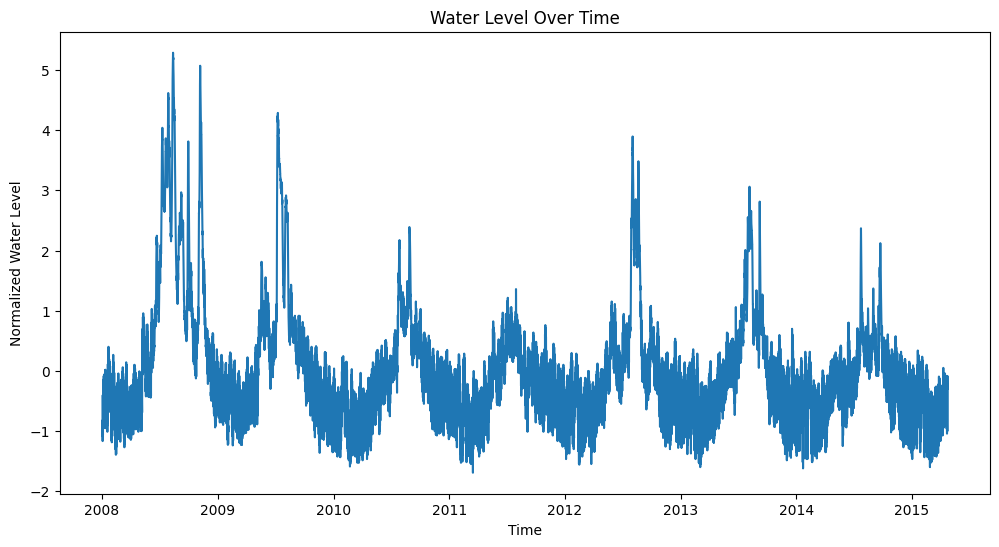

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Waterlevel'])
plt.title('Water Level Over Time')
plt.xlabel('Time')
plt.ylabel('Normalized Water Level')
plt.show()

In [10]:
def create_timesteps(data, timesteps):
    x, y = [], []
    for i in range(len(data) - timesteps):
        x.append(data[i:(i + timesteps), np.newaxis])  
        y.append(data[i + timesteps])
    return np.array(x), np.array(y)

timesteps = 18
x, y = create_timesteps(data['Waterlevel'].values[:, np.newaxis], timesteps) 

train_size = int(len(x) * 0.8)
val_size = int(len(x) * 0.1)
test_size = len(x) - train_size - val_size


x_train, y_train = x[:train_size], y[:train_size]
x_val, y_val = x[train_size:train_size + val_size], y[train_size:train_size + val_size]
x_test, y_test = x[train_size + val_size:], y[train_size + val_size:]

print(f'x_train shape: {x_train.shape}, y_train shape: {y_train.shape}')
print(f'x_val shape: {x_val.shape}, y_val shape: {y_val.shape}')
print(f'x_test shape: {x_test.shape}, y_test shape: {y_test.shape}')


x_train shape: (51234, 18, 1, 1), y_train shape: (51234, 1)
x_val shape: (6404, 18, 1, 1), y_val shape: (6404, 1)
x_test shape: (6405, 18, 1, 1), y_test shape: (6405, 1)


In [11]:
model = Sequential([
        Conv1D(filters=8, kernel_size=3, activation='relu', padding = 'same', input_shape=(timesteps, 1)),
        MaxPooling1D(pool_size=2, strides=2),
        Conv1D(filters=16, kernel_size=3, activation='relu',padding = 'same'),
        MaxPooling1D(pool_size=2, strides=2),
        Conv1D(filters=32, kernel_size=3, activation='relu', padding = 'same'),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding = 'same'),
        MaxPooling1D(pool_size=2, strides=2),
        Conv1D(filters=128, kernel_size=3, activation='relu', padding = 'same'),
        MaxPooling1D(pool_size=2, strides=2),
        Flatten(),
        Dense(50, activation='relu'),
        Dense(1, activation='relu'),
    ])


In [12]:
model.compile(optimizer=Adam(learning_rate=0.00001), loss='mse', metrics=['mean_squared_error'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.fit(x_train, y_train, epochs=50, validation_data=(x_val, y_val), batch_size=10, verbose=1, callbacks=[early_stop])

Epoch 1/50


5124/5124 [==============================] - 78s 13ms/step - loss: 0.3924 - mean_squared_error: 0.3924 - val_loss: 0.3941 - val_mean_squared_error: 0.3941
Epoch 2/50
5124/5124 [==============================] - 56s 11ms/step - loss: 0.2615 - mean_squared_error: 0.2615 - val_loss: 0.3870 - val_mean_squared_error: 0.3870
Epoch 3/50
5124/5124 [==============================] - 46s 9ms/step - loss: 0.2579 - mean_squared_error: 0.2579 - val_loss: 0.3864 - val_mean_squared_error: 0.3864
Epoch 4/50
5124/5124 [==============================] - 55s 11ms/step - loss: 0.2571 - mean_squared_error: 0.2571 - val_loss: 0.3861 - val_mean_squared_error: 0.3861
Epoch 5/50
5124/5124 [==============================] - 63s 12ms/step - loss: 0.2566 - mean_squared_error: 0.2566 - val_loss: 0.3859 - val_mean_squared_error: 0.3859
Epoch 6/50
5124/5124 [==============================] - 62s 12ms/step - loss: 0.2563 - mean_squared_error: 0.2563 - val_loss: 0.3858 - val_mean_squared_error: 0.3858
Epo

In [13]:
y_pred_cnn = model.predict(x_test).flatten()
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_cnn_rescaled = scaler.inverse_transform(y_pred_cnn.reshape(-1, 1)).flatten()

201/201 [==============================] - 2s 7ms/step


In [14]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r, _ = pearsonr(y_true, y_pred)
    T = len(y_true)
    max_x = max(y_true)
    min_x = min(y_true)
    sim_sum = 0
    for i in range(T):
        sim_sum += 1 / (1 + abs(y_pred[i] - y_true[i]) / (max_x - min_x))
    sim = sim_sum / T
    sd_y = np.std(y_pred)
    sd_x = np.std(y_test)
    fsd = 2 * np.abs(sd_y - sd_x) / (sd_y + sd_x)
    nse = 1 - (np.sum((y_pred - y_true) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R': r,
        'SIM': sim,
        'FSD': fsd,
        'NSE': nse
    }

metrics_cnn = calculate_metrics(y_test_rescaled, y_pred_cnn_rescaled)
print("Metrics for CNN model:", metrics_cnn)



Metrics for CNN model: {'MAE': 41.323797254837835, 'RMSE': 57.04085552108804, 'R': 0.8191502211452413, 'SIM': 0.90552620251368, 'FSD': 1.9207251830482597, 'NSE': 0.13273700676977818}


In [15]:
def forecast(model, initial_data, steps):
    prediction = []
    input_data = initial_data.copy()
    for i in range(steps):
        next_step = model.predict(input_data[np.newaxis, :, :])
        next_step = np.clip(next_step, 0, None)
        prediction.append(float(next_step.flatten()[0]))  
        input_data = np.roll(input_data, -1, axis=0)
        input_data[-1] = float(next_step)
    return np.array(prediction)

time_steps_forecast = [12, 24, 36, 72]
results = []
for steps in time_steps_forecast:
    predictions = forecast(model, x_test[0], steps)
    true_values = y_test[:steps]
    mse = mean_squared_error(true_values, predictions)
    results.append((steps, mse))
    print(f"Forecast for {steps} hours: MSE = {mse}")

1/1 [==============================] - 0s 68ms/step
Forecast for 12 hours: MSE = 0.0006535111544132264
1/1 [==============================] - 0s 60ms/step
Forecast for 24 hours: MSE = 0.0007772796495883622
1/1 [==============================] - 0s 55ms/step
Forecast for 36 hours: MSE = 0.0014293992219404227
1/1 [==============================] - 0s 55ms/step
Forecast for 72 hours: MSE = 0.024145375116606946


201/201 [==============================] - 1s 7ms/step
Forecast for 12 hours: MSE = 0.0006535111544132264
Predict for 12 hours: MSE = 0.00026356654606071587


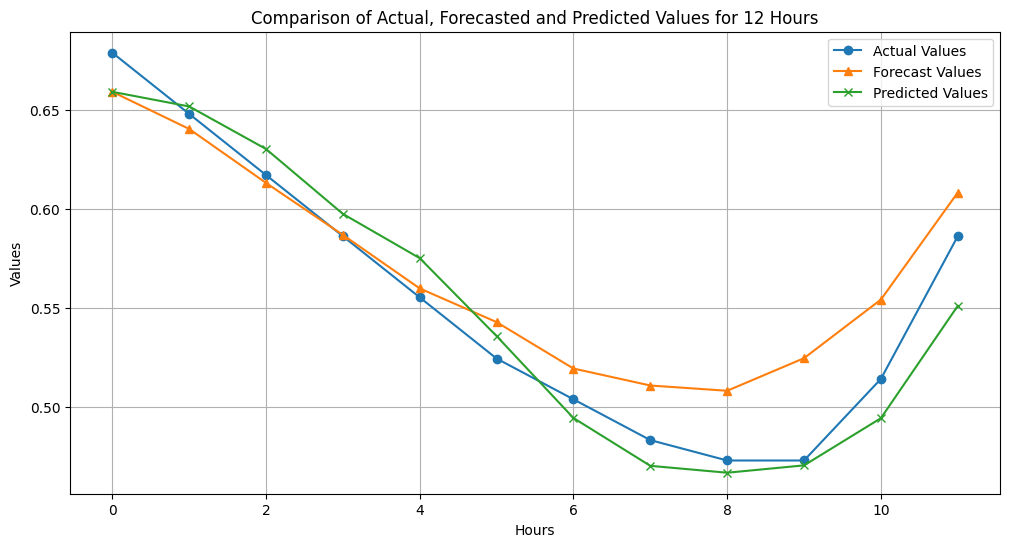

201/201 [==============================] - 1s 5ms/step
Forecast for 24 hours: MSE = 0.0007772796495883622
Predict for 24 hours: MSE = 0.0004567068157290419


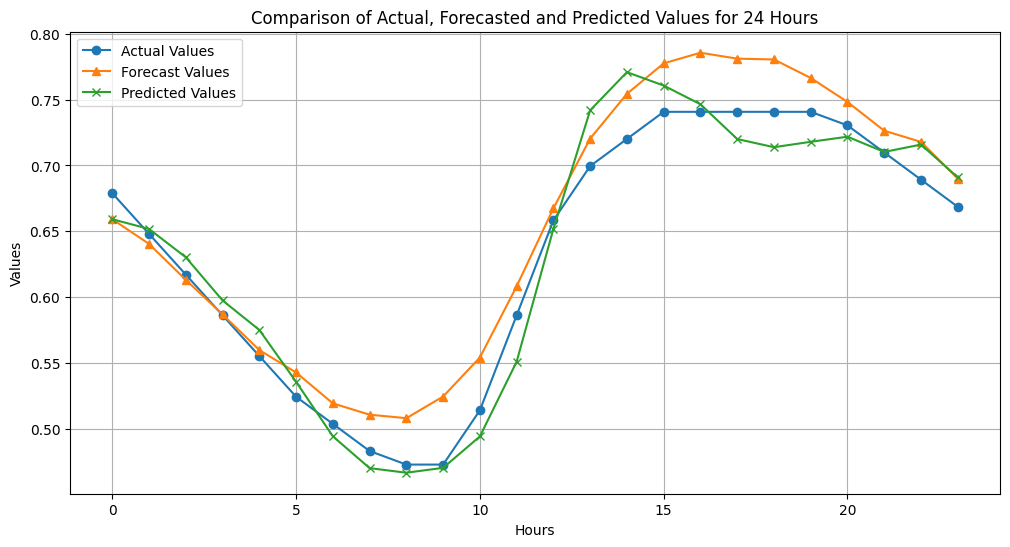

201/201 [==============================] - 1s 5ms/step
Forecast for 36 hours: MSE = 0.0014293992219404227
Predict for 36 hours: MSE = 0.00033079602054353905


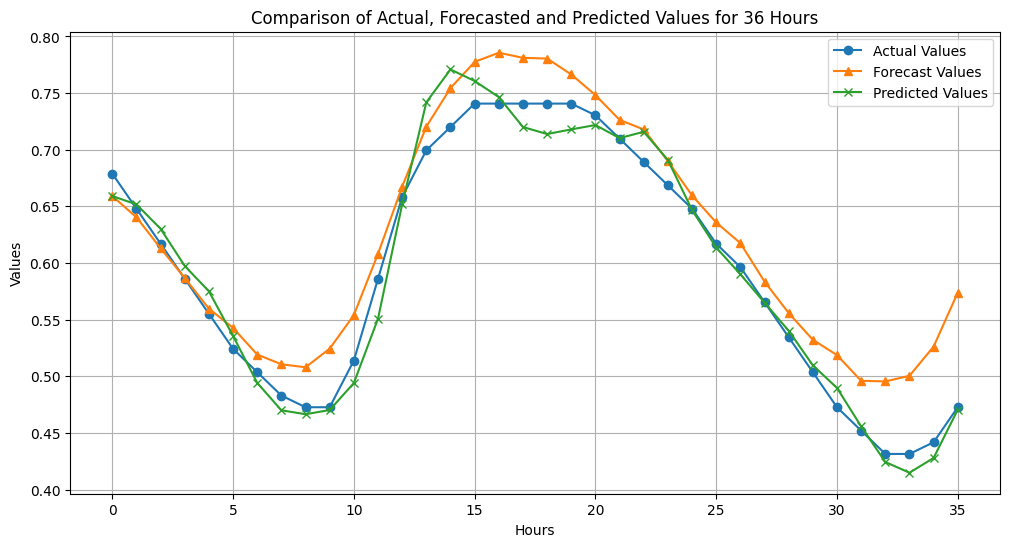

201/201 [==============================] - 1s 5ms/step
Forecast for 72 hours: MSE = 0.024145375116606946
Predict for 72 hours: MSE = 0.0004663606989380167


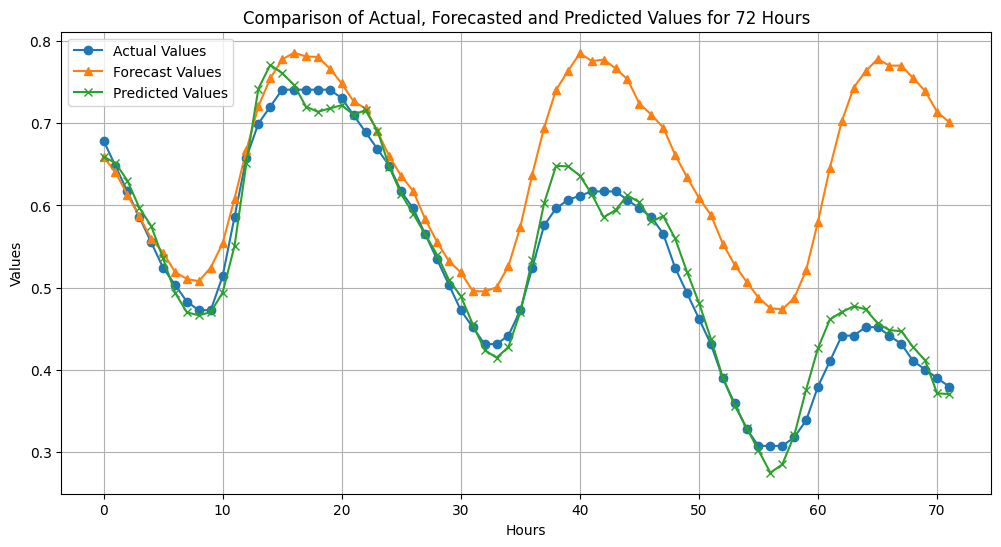

In [16]:
def plot_predictions(time_steps_forecast, model, x_test, y_test):
    for steps in time_steps_forecast:
        forecast_values = forecast(model, x_test[0], steps)
        predict_values = model.predict(x_test)[:steps].flatten()
        true_values = y_test[:steps]
        mse_forecast = mean_squared_error(true_values, forecast_values)
        mse_predict = mean_squared_error(true_values, predict_values)
        results.append((steps, mse_forecast, mse_predict))
        print(f"Forecast for {steps} hours: MSE = {mse_forecast}")
        print(f"Predict for {steps} hours: MSE = {mse_predict}")
        

        plt.figure(figsize=(12, 6))
        plt.plot(range(steps), true_values, label='Actual Values', marker='o')
        plt.plot(range(steps), forecast_values, label='Forecast Values', marker='^')
        plt.plot(range(steps), predict_values, label='Predicted Values', marker='x')
        plt.title(f'Comparison of Actual, Forecasted and Predicted Values for {steps} Hours')
        plt.xlabel('Hours')
        plt.ylabel('Values')
        plt.legend()
        plt.grid(True)
        plt.show()
plot_predictions(time_steps_forecast, model, x_test, y_test)